# Confusion matrix plotting for multi-label CTI/TTP results

This notebook loads exported `pair_confusion.csv` and `label_metrics.csv` files and plots:

1. A **pair-confusion heatmap** (`true_label_missed` × `pred_label_extra`) for multi-label error analysis.
2. Optional **top-k per-label FN/FP bar charts** from `label_metrics.csv`.
3. A **baseline vs augmented** per-label comparison.


In [93]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- User inputs ---
# PAIR_CONFUSION_CSV = Path('/home/simonettos/thijs/classification/classification/analysis/tram__ehsanaghaei_SecureBERT__pair_confusion.csv')
# LABEL_METRICS_CSV = Path('/home/simonettos/thijs/classification/classification/analysis/tram__ehsanaghaei_SecureBERT__label_metrics.csv')

# PAIR_CONFUSION_CSV_AUG = Path('/home/simonettos/thijs/classification/classification/analysis/tram_all_in__ehsanaghaei_SecureBERT__pair_confusion.csv')
# LABEL_METRICS_CSV_AUG = Path('/home/simonettos/thijs/classification/classification/analysis/tram_all_in__ehsanaghaei_SecureBERT__label_metrics.csv')


# --- User inputs ---
PAIR_CONFUSION_CSV_BOSCH = Path('/home/simonettos/thijs/classification/classification/analysis/bosch_t__FacebookAI_roberta-large__pair_confusion.csv')
LABEL_METRICS_CSV_BOSCH = Path('/home/simonettos/thijs/classification/classification/analysis/bosch_t__FacebookAI_roberta-large__label_metrics.csv')

PAIR_CONFUSION_CSV_AUG_BOSCH = Path('/home/simonettos/thijs/classification/classification/analysis/bosch_augmented_hierarchy_embeddings__FacebookAI_roberta_large__pair_confusion.csv')
LABEL_METRICS_CSV_AUG_BOSCH = Path('/home/simonettos/thijs/classification/classification/analysis/bosch_augmented_hierarchy_embeddings__FacebookAI_roberta_large__label_metrics.csv')


PAIR_CONFUSION_CSV_TRAM = Path('/home/simonettos/thijs/classification/classification/analysis/tram__ehsanaghaei_SecureBERT__pair_confusion.csv')
LABEL_METRICS_CSV_TRAM = Path('/home/simonettos/thijs/classification/classification/analysis/tram__ehsanaghaei_SecureBERT__label_metrics.csv')

PAIR_CONFUSION_CSV_AUG_TRAM = Path('/home/simonettos/thijs/classification/classification/analysis/tram_all_in__ehsanaghaei_SecureBERT__pair_confusion.csv')
LABEL_METRICS_CSV_AUG_TRAM = Path('/home/simonettos/thijs/classification/classification/analysis/tram_all_in__ehsanaghaei_SecureBERT__label_metrics.csv')

TOP_K = 35
SAVE_FIGURES = False
OUTDIR = Path('/home/simonettos/thijs/classification/classification/analysis/confusion_plots')
OUTDIR.mkdir(parents=True, exist_ok=True)
print('Ready.')

Ready.


In [94]:
def load_pair_confusion(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    expected = {'true_label_missed', 'pred_label_extra', 'count'}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f'{csv_path} is missing columns: {missing}')
    return df

def load_label_metrics(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    expected = {'label', 'support_true', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1'}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f'{csv_path} is missing columns: {missing}')
    return df

def make_pair_confusion_matrix(pair_df: pd.DataFrame, top_k: int = 20) -> pd.DataFrame:
    top_true = pair_df.groupby('true_label_missed')['count'].sum().sort_values(ascending=False).head(top_k).index
    top_pred = pair_df.groupby('pred_label_extra')['count'].sum().sort_values(ascending=False).head(top_k).index
    filtered = pair_df[pair_df['true_label_missed'].isin(top_true) & pair_df['pred_label_extra'].isin(top_pred)].copy()
    mat = filtered.pivot_table(index='true_label_missed', columns='pred_label_extra', values='count', aggfunc='sum', fill_value=0)
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index, mat.sum(axis=0).sort_values(ascending=False).index]
    return mat

def plot_heatmap(mat: pd.DataFrame, title: str, figsize_scale: float = 0.55):
    if mat.empty:
        print('Matrix is empty; nothing to plot.')
        return None
    h, w = mat.shape
    fig_w = max(8, w * figsize_scale)
    fig_h = max(6, h * figsize_scale)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(mat.values, aspect='auto')
    ax.set_xticks(np.arange(w))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_yticks(np.arange(h))
    ax.set_yticklabels(mat.index)
    ax.set_xlabel('Predicted extra label')
    ax.set_ylabel('True missed label')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if h <= 20 and w <= 20:
        vmax = mat.values.max() if mat.values.size else 0
        for i in range(h):
            for j in range(w):
                val = int(mat.iat[i, j])
                if val != 0:
                    color = 'white' if vmax and val > vmax * 0.5 else 'black'
                    ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)
    plt.tight_layout()
    return fig

def plot_top_bar(df: pd.DataFrame, column: str, title: str, top_k: int = 20):
    sub = df.sort_values(column, ascending=False).head(top_k).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(4, top_k * 0.35)))
    ax.barh(sub['label'], sub[column])
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Label')
    plt.tight_layout()
    return fig

def compare_label_metrics(base_df: pd.DataFrame, aug_df: pd.DataFrame) -> pd.DataFrame:
    merged = base_df.merge(aug_df, on='label', suffixes=('_base', '_aug'))
    merged['delta_f1'] = merged['f1_aug'] - merged['f1_base']
    merged['delta_recall'] = merged['recall_aug'] - merged['recall_base']
    merged['delta_precision'] = merged['precision_aug'] - merged['precision_base']
    merged['delta_fn'] = merged['fn_base'] - merged['fn_aug']
    merged['delta_fp'] = merged['fp_base'] - merged['fp_aug']
    return merged.sort_values('delta_f1', ascending=False).reset_index(drop=True)

print('Helpers loaded.')

Helpers loaded.


## 1) Plot a multi-label pair-confusion heatmap

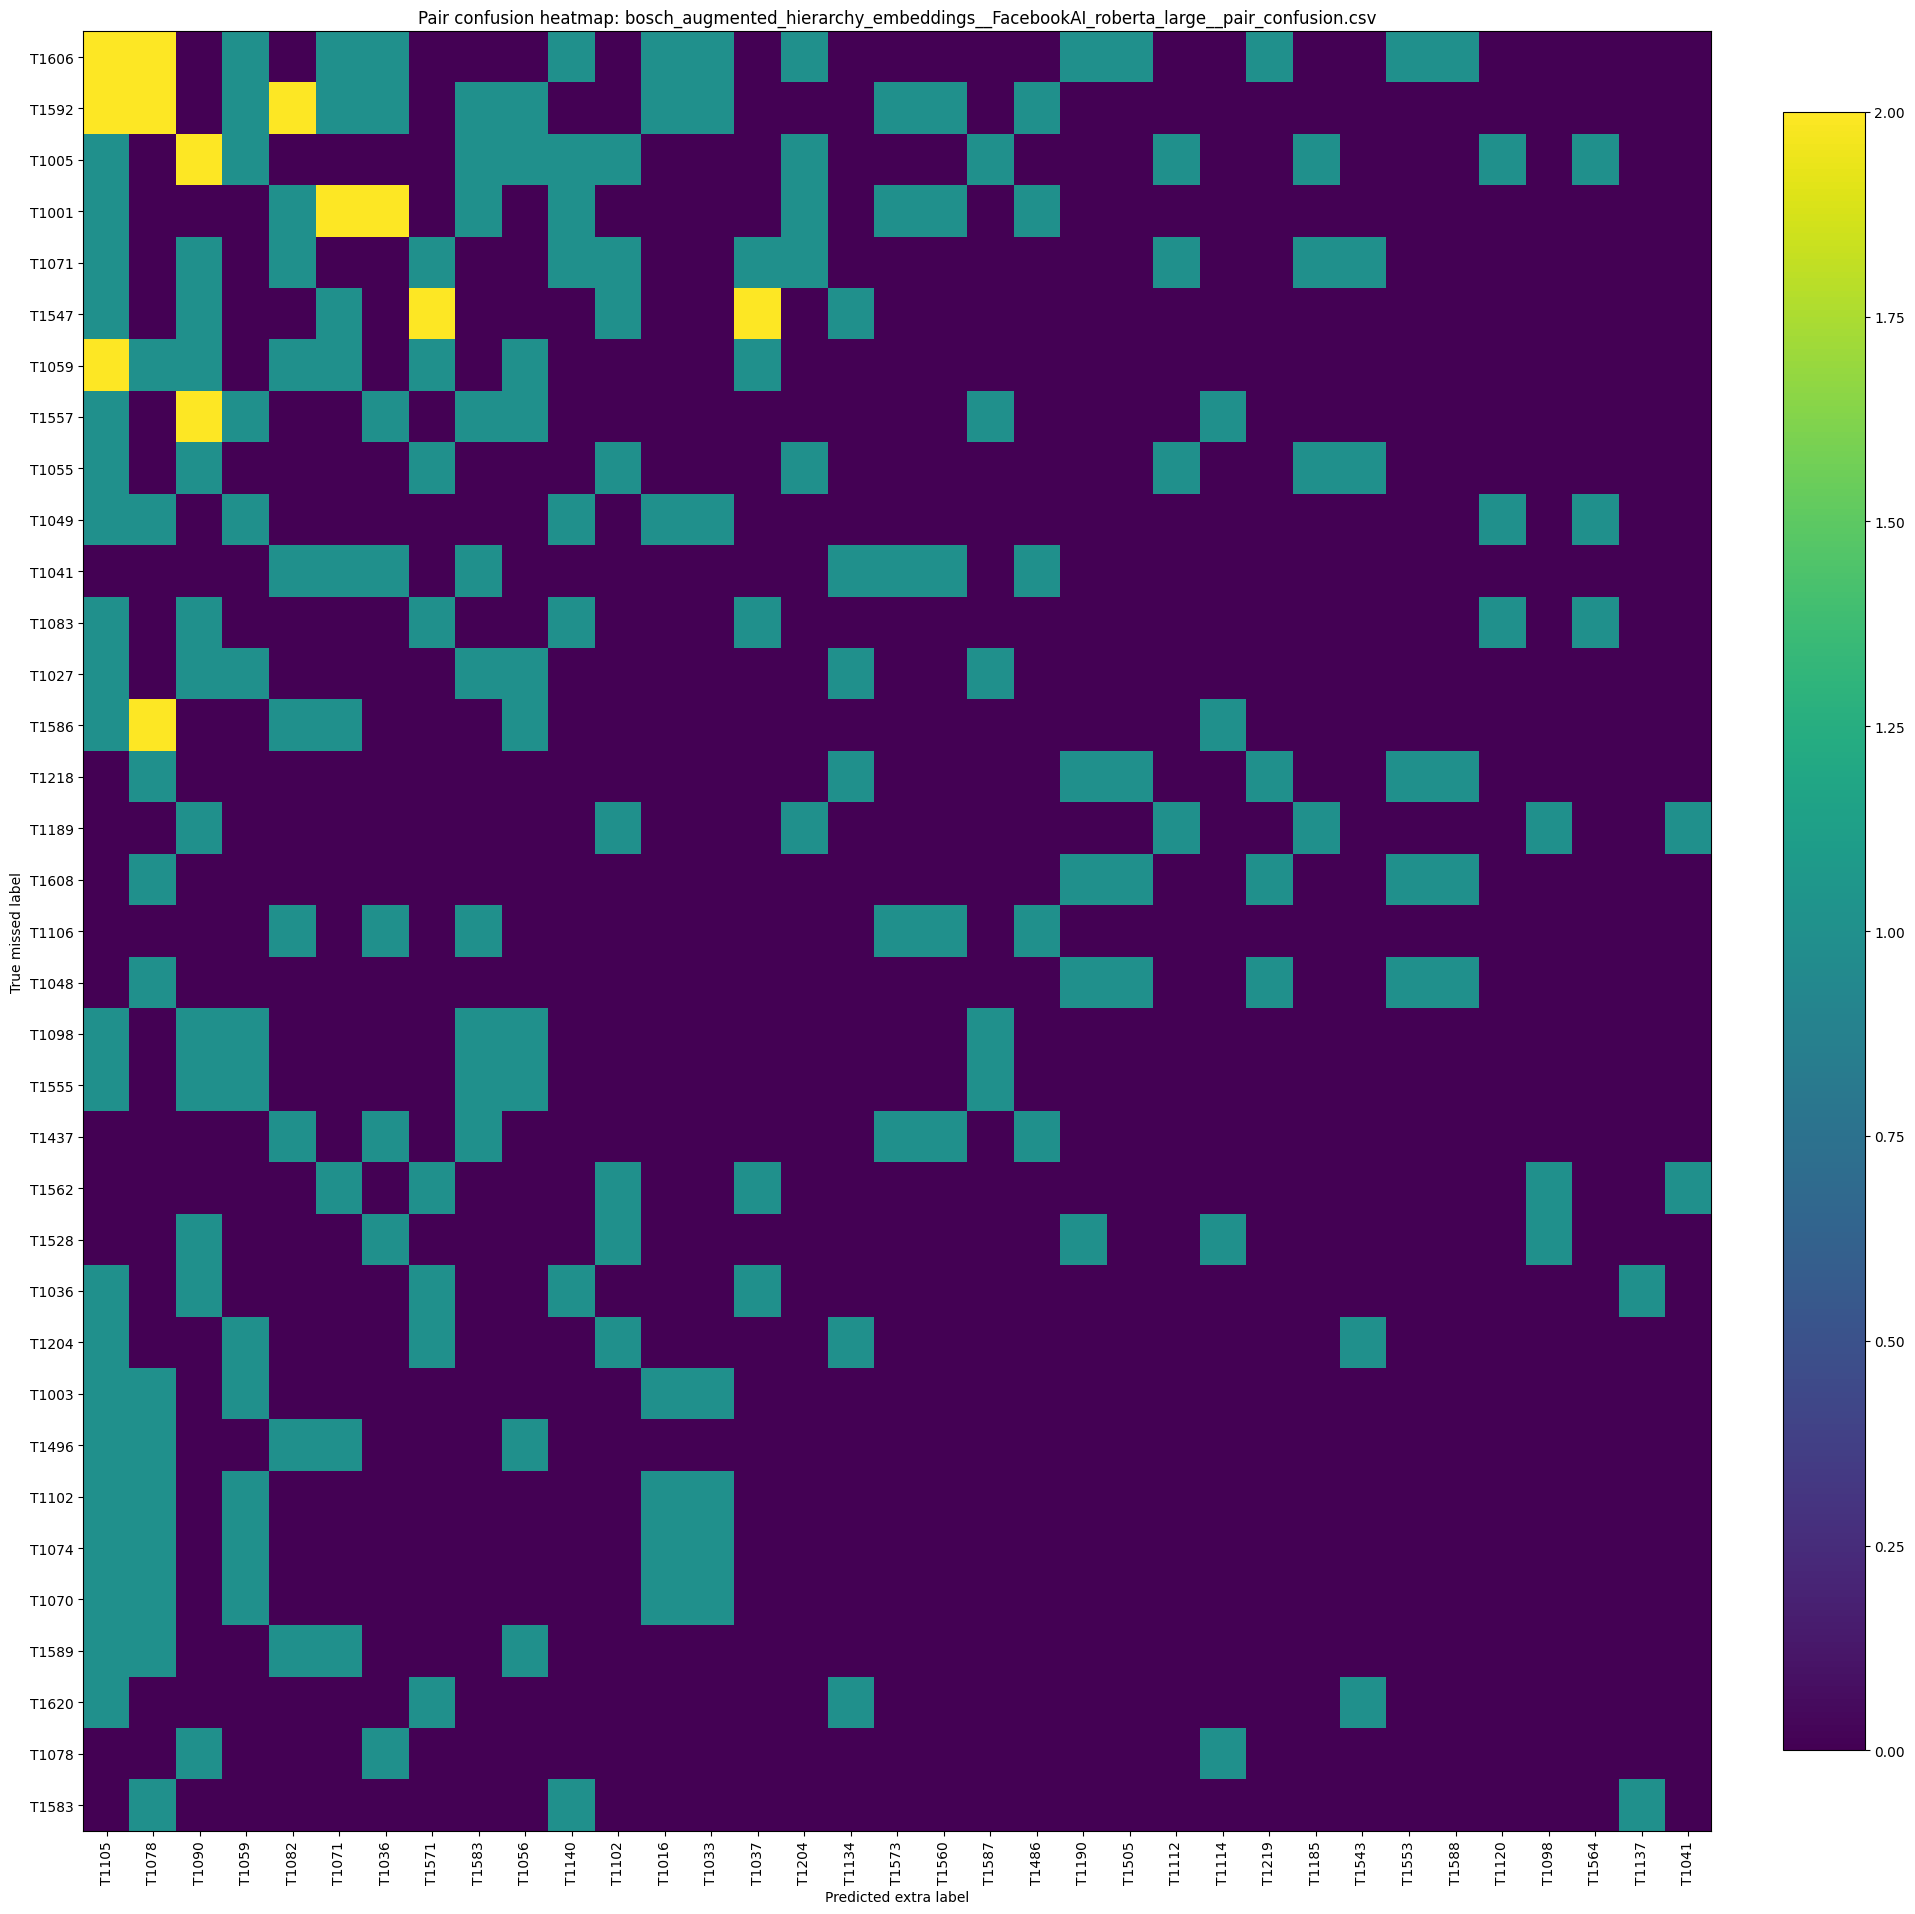

In [95]:
pair_df = load_pair_confusion(PAIR_CONFUSION_CSV_AUG)
mat = make_pair_confusion_matrix(pair_df, top_k=TOP_K)
fig = plot_heatmap(mat, title=f'Pair confusion heatmap: {PAIR_CONFUSION_CSV_AUG.name}')

if SAVE_FIGURES and fig is not None:
    outpath = OUTDIR / f'{PAIR_CONFUSION_CSV_AUG.stem}__pair_confusion_heatmap.png'
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    print('Saved to', outpath)

plt.show()

## 2) Plot top labels by false negatives / false positives

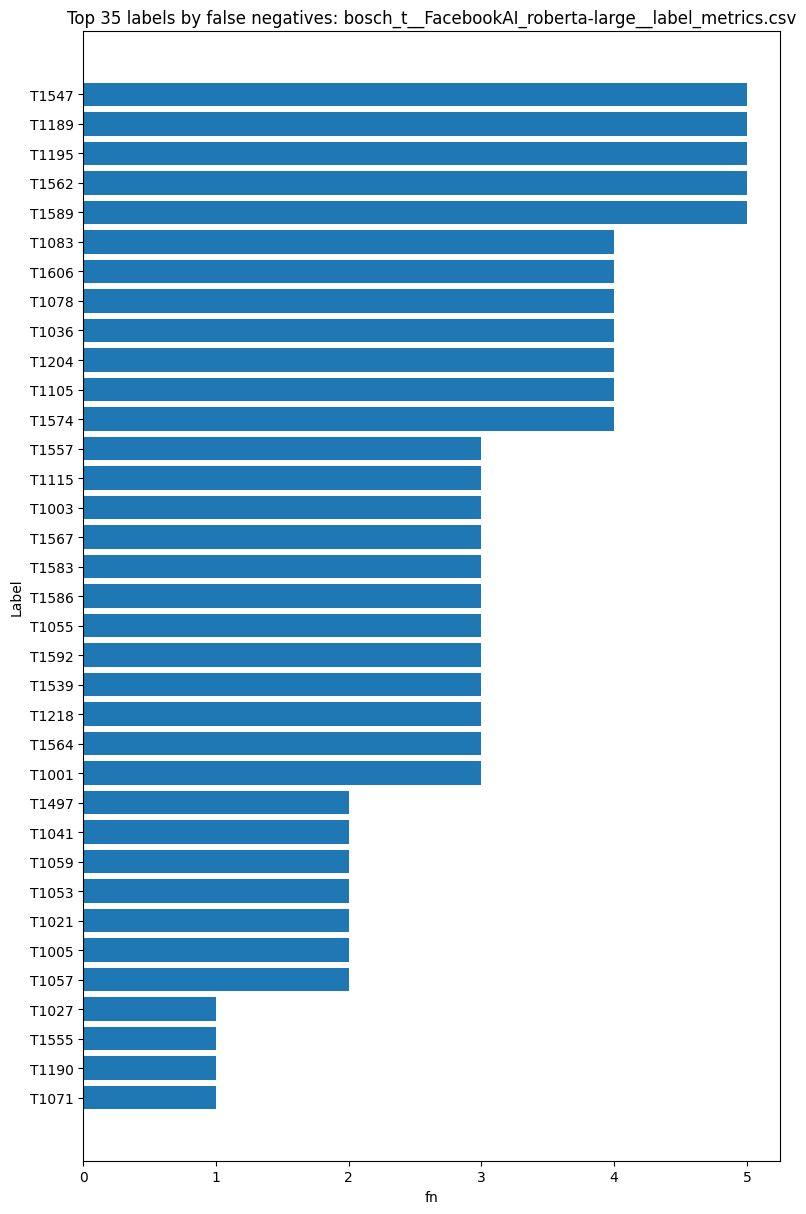

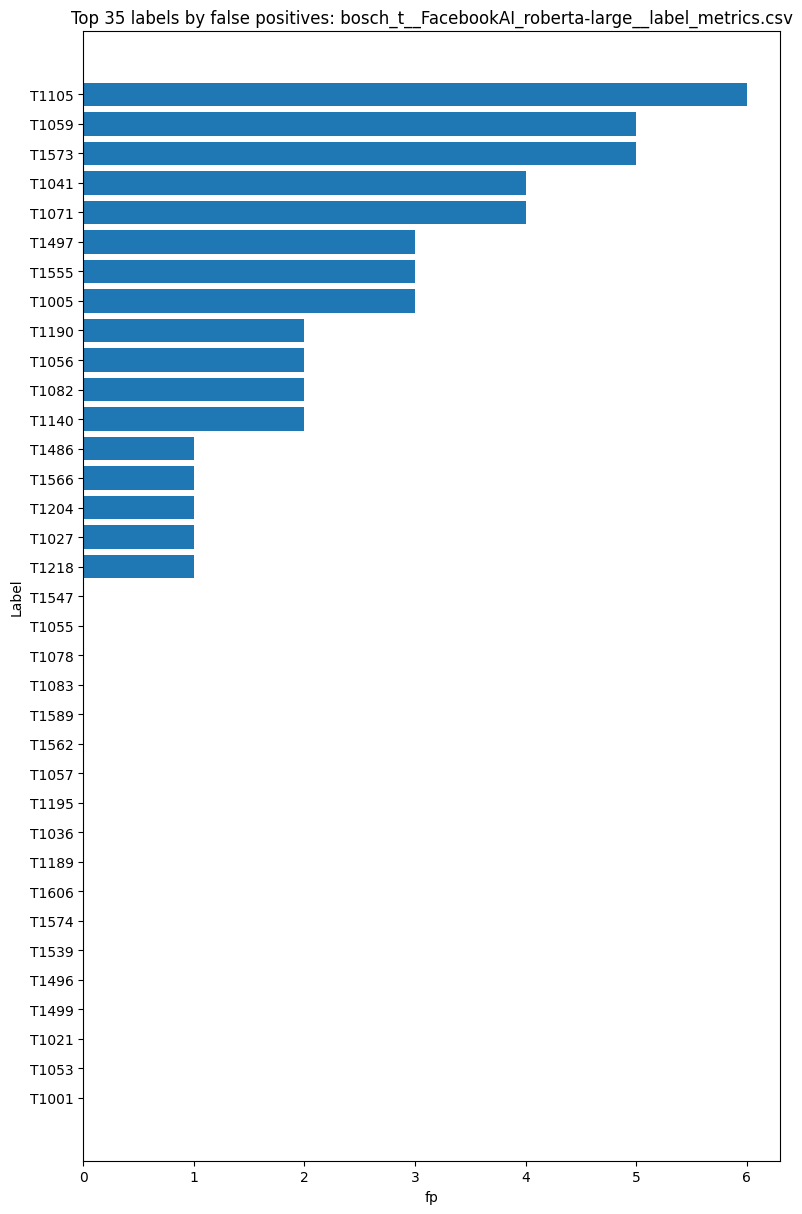

In [96]:
label_df = load_label_metrics(LABEL_METRICS_CSV)

fig1 = plot_top_bar(label_df, 'fn', f'Top {TOP_K} labels by false negatives: {LABEL_METRICS_CSV.name}', top_k=TOP_K)
fig2 = plot_top_bar(label_df, 'fp', f'Top {TOP_K} labels by false positives: {LABEL_METRICS_CSV.name}', top_k=TOP_K)

if SAVE_FIGURES:
    out1 = OUTDIR / f'{LABEL_METRICS_CSV.stem}__top_fn.png'
    out2 = OUTDIR / f'{LABEL_METRICS_CSV.stem}__top_fp.png'
    fig1.savefig(out1, dpi=300, bbox_inches='tight')
    fig2.savefig(out2, dpi=300, bbox_inches='tight')
    print('Saved to', out1)
    print('Saved to', out2)

plt.show()

## 3) Compare baseline vs augmented model per label

In [97]:
base_df = load_label_metrics(LABEL_METRICS_CSV_TRAM)
aug_df = load_label_metrics(LABEL_METRICS_CSV_AUG_TRAM)
cmp_df_tram = compare_label_metrics(base_df, aug_df)

cmp_df_tram[['label', 'support_true_base', 'f1_base', 'f1_aug', 'delta_f1', 'delta_recall', 'delta_precision', 'delta_fn', 'delta_fp']].head(50)

base_df = load_label_metrics(LABEL_METRICS_CSV_BOSCH)
aug_df = load_label_metrics(LABEL_METRICS_CSV_AUG_BOSCH)
cmp_df_bosch = compare_label_metrics(base_df, aug_df)

cmp_df_tram[['label', 'support_true_base', 'f1_base', 'f1_aug', 'delta_f1', 'delta_recall', 'delta_precision', 'delta_fn', 'delta_fp']].head(50)

,label,support_true_base,f1_base,f1_aug,delta_f1,delta_recall,delta_precision,delta_fn,delta_fp
0,T1012,3,0.000000,0.857143,8.571429e-01,1.000000,0.750000,3,-1
1,T1033,6,0.000000,0.727273,7.272727e-01,0.666667,0.800000,4,-1
2,T1005,10,0.000000,0.636364,6.363636e-01,0.700000,0.583333,7,-5
3,T1552.001,3,0.000000,0.500000,5.000000e-01,0.333333,1.000000,1,0
4,T1016,5,0.461538,0.666667,2.051282e-01,0.400000,0.125000,2,0
5,T1047,5,0.600000,0.800000,2.000000e-01,0.200000,0.200000,1,1
6,T1543.003,4,0.571429,0.750000,1.785714e-01,0.250000,0.083333,1,0
7,T1547.001,6,0.666667,0.800000,1.333333e-01,0.166667,0.000000,1,0
8,T1078,15,0.769231,0.857143,8.791209e-02,0.133333,0.013986,2,0
9,T1219,4,0.600000,0.666667,6.666667e-02,0.250000,0.000000,1,-1


In [98]:
base_df = load_label_metrics(LABEL_METRICS_CSV)
aug_df = load_label_metrics(LABEL_METRICS_CSV_AUG)
cmp_df = compare_label_metrics(base_df, aug_df)

cmp_df[['label', 'support_true_base', 'f1_base', 'f1_aug', 'delta_f1', 'delta_recall', 'delta_precision', 'delta_fn', 'delta_fp']].head(50)

,label,support_true_base,f1_base,f1_aug,delta_f1,delta_recall,delta_precision,delta_fn,delta_fp
0,T1567,3,0.000000,1.000000,1.000000,1.000000,1.000000,3,0
1,T1574,4,0.000000,0.857143,0.857143,0.750000,1.000000,3,0
2,T1564,3,0.000000,0.857143,0.857143,1.000000,0.750000,3,-1
3,T1003,3,0.000000,0.800000,0.800000,0.666667,1.000000,2,0
4,T1115,3,0.000000,0.800000,0.800000,0.666667,1.000000,2,0
5,T1562,5,0.000000,0.750000,0.750000,0.600000,1.000000,3,0
6,T1589,5,0.000000,0.750000,0.750000,0.600000,1.000000,3,0
7,T1539,4,0.400000,1.000000,0.600000,0.750000,0.000000,3,0
8,T1557,3,0.000000,0.500000,0.500000,0.333333,1.000000,1,0
9,T1083,5,0.333333,0.750000,0.416667,0.400000,0.000000,2,0


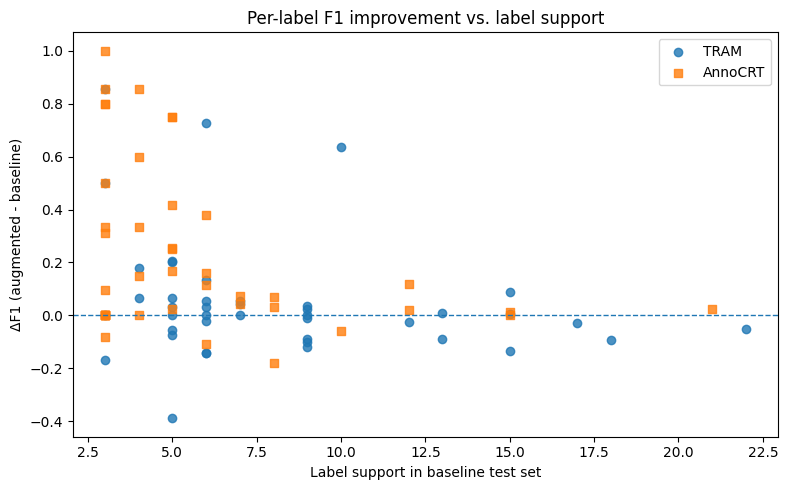

In [99]:
import matplotlib.pyplot as plt

# Sort for readability, optional
plot_df_tram = cmp_df_tram.copy()
plot_df_bosch = cmp_df_bosch.copy()
fig, ax = plt.subplots(figsize=(8, 5))

# --- TRAM ---
ax.scatter(
    plot_df_tram["support_true_base"],
    plot_df_tram["delta_f1"],
    alpha=0.8,
    label="TRAM",
    marker="o"
)

# --- AnnoCRT / Bosch ---
ax.scatter(
    plot_df_bosch["support_true_base"],
    plot_df_bosch["delta_f1"],
    alpha=0.8,
    label="AnnoCRT",
    marker="s"
)

# Horizontal reference line
ax.axhline(0, linestyle="--", linewidth=1)

# Labels
ax.set_xlabel("Label support in baseline test set")
ax.set_ylabel("ΔF1 (augmented - baseline)")
ax.set_title("Per-label F1 improvement vs. label support")

# Legend
ax.legend()

plt.tight_layout()
plt.show()